In [29]:
%load_ext autoreload
%autoreload 2

In [30]:
import contextlib
import copy
import io
import os
import queue
import threading
from datetime import date
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
from scipy.optimize import differential_evolution
from sklearn.metrics import root_mean_squared_error, r2_score

from aquacrop import AquaCrop, Crop, Soil, Weather
from aquacrop_slovenia import config
from aquacrop_slovenia.diagnostics import nse, kge, mkge, kge_r, kge_beta, kge_alpha, mkge_alpha
from aquacrop_slovenia.plots import plot_yield_timeseries_comparison, plot_yield_scatter, plot_yield_timeseries_residuals
from aquacrop_slovenia.reading_data import get_yield, get_yield_for_comparison, get_co2_for_aquacrop, get_station_weather
from aquacrop_slovenia.parameter_defaults_jablje import (
    jablje_soil_layers,
    jablje_curve_number,
    jablje_readily_evaporable_water,
    jablje_maize_params,
    jablje_optimal_management,
    jablje_initial_cond,
    jablje_groundwater,
)

In [31]:
LOCATION = "jablje"
MAX_WORKERS = os.cpu_count()

simulation_periods = [
    {
        "start_date": date(year, 1, 1),
        "end_date": date(year, 12, 31),
        "planting_date": date(year, 5, 3),
        "is_seeding_year": True,
    }
    for year in range(1993, 2024)
    if year not in [2017]
]

temperatures, eto, rain = get_station_weather(8)
historical_co2 = get_co2_for_aquacrop("historical")

weather = Weather(
    location=LOCATION,
    temperatures=temperatures,
    eto_values=eto,
    rainfall_values=rain,
    record_type=1,
    first_day=1,
    first_month=1,
    first_year=1993,
    co2_records=historical_co2,
)

soil = Soil(
    name=f"{LOCATION} soil",
    description=f"{LOCATION} loamy sand soil",
    soil_layers=jablje_soil_layers,
    curve_number=jablje_curve_number,
    readily_evaporable_water=jablje_readily_evaporable_water,
)

observed_biomass = get_yield_for_comparison(LOCATION, "biomass", "A", "N3")
observed_grain   = get_yield_for_comparison(LOCATION, "grain",   "A", "N3")

INTEGER_PARAMS = {name for name, val in jablje_maize_params.items() if isinstance(val, int)}

In [32]:
worker_dirs = []
for i in range(MAX_WORKERS):
    d = config.RAMDISK_DIR / f"de_jablje_{i}"
    d.mkdir(parents=True, exist_ok=True)
    worker_dirs.append(d)

dir_queue = queue.Queue()
for d in worker_dirs:
    dir_queue.put(d)

print(f"Worker directories ready: {MAX_WORKERS}")

In [33]:
# Parameter names and search bounds (same ranges as grid search)
param_names = [
    "harvest_index",
    "gdd_senescence",
    "gdd_maturity",
    "gdd_flowering",
    "gdd_flowering_length",
    "max_canopy_cover",
]

bounds = [
    (0.46, 0.56),   # harvest_index
    (1000, 1150),   # gdd_senescence
    (1200, 1400),   # gdd_maturity
    (480,  530),    # gdd_flowering
    (130,  170),    # gdd_flowering_length
    (0.85, 0.95),   # max_canopy_cover
]

print(f"Parameters: {param_names}")
print(f"Bounds:     {bounds}")

In [34]:
def evaluate_params(param_values):
    """Run one candidate and return all metrics for both grain and biomass."""
    working_dir = dir_queue.get()
    try:
        params = copy.deepcopy(jablje_maize_params)
        for name, val in zip(param_names, param_values):
            params[name] = int(round(val)) if name in INTEGER_PARAMS else float(val)

        crop = Crop(
            name=f"{LOCATION} maize",
            description="differential evolution",
            params=params,
        )

        simulation = AquaCrop(
            simulation_periods=simulation_periods,
            crop=crop,
            soil=soil,
            management=jablje_optimal_management,
            initial_conditions=jablje_initial_cond,
            climate=weather,
            #ground_water=jablje_groundwater,
            working_dir=working_dir,
            need_daily_output=False,
            need_seasonal_output=True,
            need_harvest_output=False,
            need_evaluation_output=False,
        )

        nan_metrics = {
            f"{prefix}_{s}": np.nan
            for prefix in ("biomass", "grain")
            for s in ["rmse", "r2", "nse", "kge", "mkge", "kge_r", "kge_beta", "kge_alpha", "mkge_alpha"]
        }

        try:
            with contextlib.redirect_stdout(io.StringIO()):
                results = simulation.run()
        except Exception:
            return nan_metrics

        seasonal = results["season"][["Year1", "BioMass", "Y(dry)"]].rename(
            columns={"Year1": "year", "BioMass": "biomass_modeled", "Y(dry)": "grain_modeled"}
        )

        def compute_metrics(observed_df, modeled_col, prefix):
            merged = observed_df.merge(seasonal[["year", modeled_col]], on="year")
            y_obs = merged["yield"].values
            y_mod = merged[modeled_col].values
            return {
                f"{prefix}_rmse":       root_mean_squared_error(y_obs, y_mod),
                f"{prefix}_r2":         r2_score(y_obs, y_mod),
                f"{prefix}_nse":        nse(y_mod, y_obs),
                f"{prefix}_kge":        kge(y_mod, y_obs),
                f"{prefix}_mkge":       mkge(y_mod, y_obs),
                f"{prefix}_kge_r":      kge_r(y_mod, y_obs),
                f"{prefix}_kge_beta":   kge_beta(y_mod, y_obs),
                f"{prefix}_kge_alpha":  kge_alpha(y_mod, y_obs),
                f"{prefix}_mkge_alpha": mkge_alpha(y_mod, y_obs),
            }

        return {
            **compute_metrics(observed_biomass, "biomass_modeled", "biomass"),
            **compute_metrics(observed_grain,   "grain_modeled",   "grain"),
        }
    finally:
        dir_queue.put(working_dir)

In [35]:
eval_log = []          # collects every evaluated candidate for post-analysis
eval_log_lock = threading.Lock()

def make_scalar_objective(objective_fn):
    """Scalar objective for one candidate (used by thread_map workers)."""
    def scalar(param_values):
        r = evaluate_params(param_values)
        with eval_log_lock:
            eval_log.append({**dict(zip(param_names, param_values)), **r})
        return objective_fn(r)
    return scalar

def thread_map(func, iterable):
    """Drop-in map replacement for scipy workers= that uses ThreadPoolExecutor."""
    items = list(iterable)
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        return list(executor.map(func, items))


mean_biomass = observed_biomass["yield"].mean()
mean_grain   = observed_grain["yield"].mean()
print(f"Mean observed biomass: {mean_biomass:.1f}  |  mean observed grain: {mean_grain:.1f}")

objectives = {
    "biomass_rmse":   make_scalar_objective(lambda r: r["biomass_rmse"]),
    "grain_rmse":     make_scalar_objective(lambda r: r["grain_rmse"]),
    "combined_nrmse": make_scalar_objective(
        lambda r: r["biomass_rmse"] / mean_biomass + r["grain_rmse"] / mean_grain
    ),
}

In [36]:
DE_SETTINGS = dict(
    bounds=bounds,
    strategy="best1bin",
    maxiter=300,
    popsize=15,          # 15 * n_params = 90 individuals per generation
    tol=1e-4,
    mutation=(0.5, 1.0),
    recombination=0.7,
    seed=42,
    workers=thread_map,  # parallel via ThreadPoolExecutor; evaluates full generation at once
    updating="deferred", # required when workers != 1
    disp=True,
)

n_pop = DE_SETTINGS["popsize"] * len(bounds)
print(f"Population size: {n_pop}  |  max evaluations: {n_pop * DE_SETTINGS['maxiter']:,}")

In [37]:
eval_log.clear()
print("=== Optimising for BIOMASS RMSE ===")
result_biomass = differential_evolution(objectives["biomass_rmse"], **DE_SETTINGS)
print(f"\nSuccess: {result_biomass.success}  |  message: {result_biomass.message}")
print(f"Function evaluations: {result_biomass.nfev}")
print(f"Best biomass RMSE: {result_biomass.fun:.4f}")
print("Best parameters:")
for name, val in zip(param_names, result_biomass.x):
    print(f"  {name}: {val:.4f}")

In [38]:
eval_log.clear()
print("=== Optimising for GRAIN RMSE ===")
result_grain = differential_evolution(objectives["grain_rmse"], **DE_SETTINGS)
print(f"\nSuccess: {result_grain.success}  |  message: {result_grain.message}")
print(f"Function evaluations: {result_grain.nfev}")
print(f"Best grain RMSE: {result_grain.fun:.4f}")
print("Best parameters:")
for name, val in zip(param_names, result_grain.x):
    print(f"  {name}: {val:.4f}")

In [39]:
eval_log.clear()
print("=== Optimising for COMBINED normalised RMSE (biomass + grain) ===")
result_combined = differential_evolution(objectives["combined_nrmse"], **DE_SETTINGS)
print(f"\nSuccess: {result_combined.success}  |  message: {result_combined.message}")
print(f"Function evaluations: {result_combined.nfev}")
print(f"Best combined nRMSE: {result_combined.fun:.6f}")
print("Best parameters:")
for name, val in zip(param_names, result_combined.x):
    print(f"  {name}: {val:.4f}")

In [40]:
# Re-evaluate each best solution to get the full metric set
de_runs = {
    "biomass_rmse":   result_biomass.x,
    "grain_rmse":     result_grain.x,
    "combined_nrmse": result_combined.x,
}

summary_rows = []
for run_name, x in de_runs.items():
    metrics = evaluate_params(x)
    row = {"optimised_for": run_name, **dict(zip(param_names, x)), **metrics}
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("optimised_for")
summary_df

,harvest_index,gdd_senescence,gdd_maturity,gdd_flowering,gdd_flowering_length,max_canopy_cover,biomass_rmse,biomass_r2,biomass_nse,biomass_kge,...,biomass_mkge_alpha,grain_rmse,grain_r2,grain_nse,grain_kge,grain_mkge,grain_kge_r,grain_kge_beta,grain_kge_alpha,grain_mkge_alpha
optimised_for,,,,,,,,,,,,,,,,,,,,,
biomass_rmse,0.478083,1000.290319,1203.050003,480.453781,130.002024,0.853438,4.418814,-0.035685,-0.035685,-0.204034,...,0.162088,2.471012,-0.450136,-0.450136,-0.086403,-0.055427,0.229935,0.845485,0.249402,0.294981
grain_rmse,0.485265,1149.797308,1295.167972,480.387533,138.699471,0.880764,5.852069,-0.816500,-0.816500,-0.164686,...,0.150724,1.982877,0.066208,0.066208,-0.011110,-0.011448,0.261739,1.001604,0.309123,0.308628
combined_nrmse,0.557173,1000.140092,1202.797573,480.091255,130.383407,0.850891,4.418814,-0.035685,-0.035685,-0.204034,...,0.162088,2.004997,0.045258,0.045258,-0.046844,-0.044128,0.229961,0.986384,0.290961,0.294977


In [49]:
display_cols = [
    "biomass_rmse", "biomass_r2", "biomass_nse", "biomass_kge", "biomass_mkge",
    "grain_rmse",   "grain_r2",   "grain_nse",   "grain_kge",   "grain_mkge",
]
print("Metric comparison across optimisation targets:")
summary_df[display_cols].round(4)

,biomass_rmse,biomass_r2,biomass_nse,biomass_kge,biomass_mkge,grain_rmse,grain_r2,grain_nse,grain_kge,grain_mkge
optimised_for,,,,,,,,,,
biomass_rmse,4.4188,-0.0357,-0.0357,-0.2040,-0.2100,2.4710,-0.4501,-0.4501,-0.0864,-0.0554
grain_rmse,5.8521,-0.8165,-0.8165,-0.1647,-0.1881,1.9829,0.0662,0.0662,-0.0111,-0.0114
combined_nrmse,4.4188,-0.0357,-0.0357,-0.2040,-0.2100,2.0050,0.0453,0.0453,-0.0468,-0.0441


In [50]:
# Collect all evaluated candidates from the last DE run (combined) into a DataFrame
all_evals_df = pd.DataFrame(eval_log)
print(f"Total evaluations stored from last run: {len(all_evals_df)}")
all_evals_df.sort_values("biomass_rmse").head(10)

,harvest_index,gdd_senescence,gdd_maturity,gdd_flowering,gdd_flowering_length,max_canopy_cover,biomass_rmse,biomass_r2,biomass_nse,biomass_kge,...,biomass_mkge_alpha,grain_rmse,grain_r2,grain_nse,grain_kge,grain_mkge,grain_kge_r,grain_kge_beta,grain_kge_alpha,grain_mkge_alpha
5487,0.559127,1000.183193,1202.878774,480.143144,130.347440,0.850482,4.418814,-0.035685,-0.035685,-0.204034,...,0.162088,2.004997,0.045258,0.045258,-0.046844,-0.044128,0.229961,0.986384,0.290961,0.294977
5108,0.559779,1000.008405,1202.959094,480.219269,130.417417,0.850852,4.418814,-0.035685,-0.035685,-0.204034,...,0.162088,2.004997,0.045258,0.045258,-0.046844,-0.044128,0.229961,0.986384,0.290961,0.294977
5106,0.555950,1000.239330,1202.886061,480.106389,130.351208,0.851843,4.418814,-0.035685,-0.035685,-0.204034,...,0.162088,2.004997,0.045258,0.045258,-0.046844,-0.044128,0.229961,0.986384,0.290961,0.294977
5098,0.559051,1000.102938,1203.025595,480.436522,130.311217,0.851542,4.418814,-0.035685,-0.035685,-0.204034,...,0.162088,2.004997,0.045258,0.045258,-0.046844,-0.044128,0.229961,0.986384,0.290961,0.294977
5492,0.557173,1000.140092,1202.797573,480.091255,130.383407,0.850891,4.418814,-0.035685,-0.035685,-0.204034,...,0.162088,2.004997,0.045258,0.045258,-0.046844,-0.044128,0.229961,0.986384,0.290961,0.294977
5485,0.557785,1000.215903,1202.957646,480.316788,130.370185,0.850381,4.418814,-0.035685,-0.035685,-0.204034,...,0.162088,2.004997,0.045258,0.045258,-0.046844,-0.044128,0.229961,0.986384,0.290961,0.294977
5474,0.555442,1000.086078,1202.507433,480.098688,130.081537,0.850373,4.418814,-0.035685,-0.035685,-0.204034,...,0.162088,2.004997,0.045258,0.045258,-0.046844,-0.044128,0.229961,0.986384,0.290961,0.294977
5473,0.557634,1000.114462,1202.562714,480.220050,130.478146,0.850585,4.418814,-0.035685,-0.035685,-0.204034,...,0.162088,2.004997,0.045258,0.045258,-0.046844,-0.044128,0.229961,0.986384,0.290961,0.294977
5472,0.558277,1000.229817,1203.027638,480.164413,130.471168,0.851527,4.418814,-0.035685,-0.035685,-0.204034,...,0.162088,2.004997,0.045258,0.045258,-0.046844,-0.044128,0.229961,0.986384,0.290961,0.294977
5471,0.557527,1000.201725,1202.787633,480.019663,130.416738,0.851061,4.418814,-0.035685,-0.035685,-0.204034,...,0.162088,2.004997,0.045258,0.045258,-0.046844,-0.044128,0.229961,0.986384,0.290961,0.294977


In [43]:
output_path = config.RESULTS_DIR / "de_jablje_summary.pkl"
summary_df.reset_index().to_pickle(output_path)
print(f"Saved summary ({len(summary_df)} rows) to {output_path}")

In [44]:
# Visualise the best solution for each target
def rerun_best(param_values, label):
    """Re-run a full simulation with given params and return seasonal results."""
    params = copy.deepcopy(jablje_maize_params)
    for name, val in zip(param_names, param_values):
        params[name] = int(round(val)) if name in INTEGER_PARAMS else float(val)

    best_dir = config.RAMDISK_DIR / f"de_jablje_best_{label}"
    best_dir.mkdir(parents=True, exist_ok=True)

    sim = AquaCrop(
        simulation_periods=simulation_periods,
        crop=Crop(name=f"{LOCATION} maize ({label})", description=label, params=params),
        soil=soil,
        management=jablje_optimal_management,
        initial_conditions=jablje_initial_cond,
        climate=weather,
        #ground_water=jablje_groundwater,
        working_dir=best_dir,
        need_daily_output=False,
        need_seasonal_output=True,
        need_harvest_output=False,
        need_evaluation_output=False,
    )
    return sim.run()["season"]

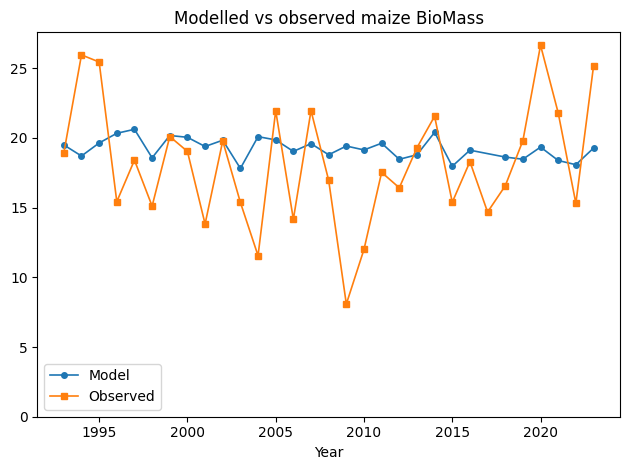

In [45]:
seasonal_biomass_opt = rerun_best(result_biomass.x, "biomass_opt")
print("=== Best solution optimised for biomass RMSE ===")
plot_yield_timeseries_comparison(seasonal_biomass_opt, get_yield(LOCATION, "biomass", "A", "N3"), "BioMass")

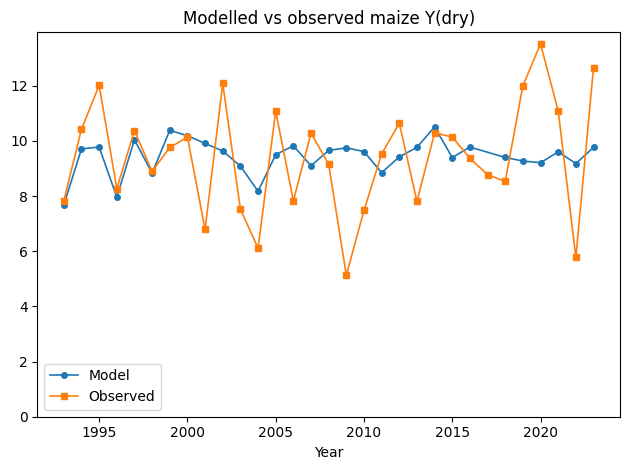

In [46]:
seasonal_grain_opt = rerun_best(result_grain.x, "grain_opt")
print("=== Best solution optimised for grain RMSE ===")
plot_yield_timeseries_comparison(seasonal_grain_opt, get_yield(LOCATION, "grain", "A", "N3"), "Y(dry)")

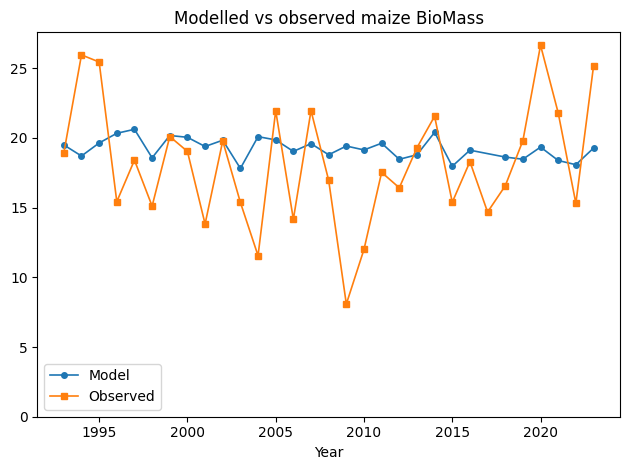

In [47]:
seasonal_combined_opt = rerun_best(result_combined.x, "combined_opt")
print("=== Best solution optimised for combined nRMSE ===")
plot_yield_timeseries_comparison(seasonal_combined_opt, get_yield(LOCATION, "biomass", "A", "N3"), "BioMass")

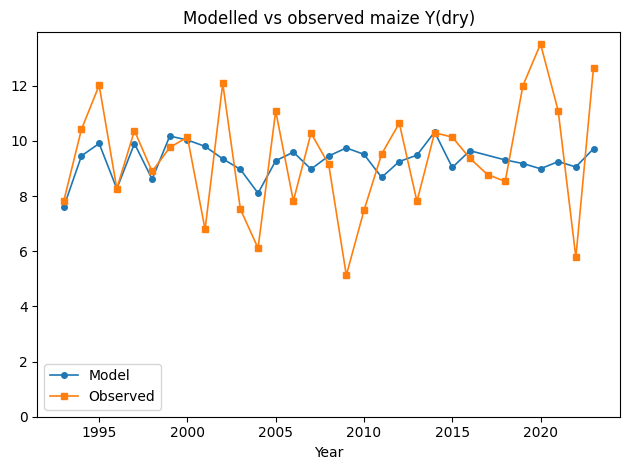

In [48]:
plot_yield_timeseries_comparison(seasonal_combined_opt, get_yield(LOCATION, "grain", "A", "N3"), "Y(dry)")